# Week 3 - Pandas and CO2 records

In week 1 we calculated the hypothetical sea-level rise that would take place if all the ice on Antarctica melted. Luckily that's a very unlikely scenario (in our lifetime). Understanding climate data is, however, a critical factor for any Earth Scientists. There is lots of relevant data freely available online and we can use this to examine changes in the Earth's atmosphere (i.e., CO2 content) and mean surface temperature over the last 45 years.

First we'll get used to some of the basic concepts of Pandas. Next, we'll apply some of this knowledge to datasets of the Mauna Loa CO2 observatory (an important, near-continuous record of atmospheric CO2 levels) and estimates of the 'global surface temperature anomaly' relative to the long-term average between 1951 and 1980. Finally, there is some reading for you to do at the end of this notebook to better understand how other types of geological data contributes to the evidence that climate change is undeniably human-caused.

# Introduction to Pandas

**Pandas** is a powerful and widely used library in Python for data manipulation and analysis. It provides easy-to-use, high-level data structures, such as:

- **Series**: A one-dimensional labeled array, similar to a list or a column in a spreadsheet.
- **DataFrame**: A two-dimensional table with labeled rows and columns, akin to a spreadsheet or SQL table.

## Key Features
- **Data Handling**: Importing data from various sources (CSV, Excel, SQL, etc.) and exporting it back.
- **Data Cleaning**: Handling missing values, filtering, and transforming data efficiently.
- **Data Analysis**: Grouping, aggregating, and performing statistical operations.
- **Indexing and Slicing**: Flexible selection of rows and columns for deeper analysis.
- **Visualization**: Integrates with libraries like Matplotlib and Seaborn for visualizing data.

## Why Use Pandas?
Pandas simplifies the process of working with structured data, making it an essential tool for data science, machine learning, and automation tasks. It empowers beginners to handle and explore data effectively with minimal code.


In [166]:
# In nearly all notebooks from this point onwards we will start with the following three lines of code
# This imports the three most commonly used Python packages: NumPy, Pandas, and Matplotlib.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Exercise 1 - Get to know your classmates (a little)

Let's first just create a simple DataFrame. Make a DataFrame with the columns ['Name', 'Birth Place', 'Pet', 'Pet Name', 'Favorite Food']. Turn to your classmates and find at least 10 people who gave give you this information to complete the DataFrame using the framework below:

(5 points)

In [167]:
Class = pd.DataFrame(columns = ['Name', 'Birth Place', 'Pet', 'Pet Name', 'Favorite Food'],
                     data = [['Matthew Gleeson', 'London', 'Dog', 'Lupin', 'Pizza'],
                             ['Itsuki Kigoshi', 'Yamaguchi','Sugar Glider', 'Charmy', '鰹のたたき'],
                             ['Bluno MacDarrah', 'Litchfield', 'Cat', 'Mochi', 'Pizza'],
                             ['Ayla Su', 'Manhattan', None, None, 'Sushi'],
                             ['Cortney Ha', 'Los Angels', None, None, 'Sushi'],
                             ['Cayla', 'San Diego', 'Dog', 'Coco', 'Cheese'],
                             ['Gagik Aghajanyan', 'Pasadena', 'Cat', 'Davo', 'Chilli Fries'],
                             ['Ramia', 'Pakistan', None, None, 'Tacos']])

Class

,Name,Birth Place,Pet,Pet Name,Favorite Food
0,Matthew Gleeson,London,Dog,Lupin,Pizza
1,Itsuki Kigoshi,Yamaguchi,Sugar Glider,Charmy,鰹のたたき
2,Bluno MacDarrah,Litchfield,Cat,Mochi,Pizza
3,Ayla Su,Manhattan,NaN,NaN,Sushi
4,Cortney Ha,Los Angels,NaN,NaN,Sushi
5,Cayla,San Diego,Dog,Coco,Cheese
6,Gagik Aghajanyan,Pasadena,Cat,Davo,Chilli Fries
7,Ramia,Pakistan,NaN,NaN,Tacos


Create a new column with a random integer between 1 and 100 for each person:

(2 points)

In [168]:

Class['Number'] = np.random.randint(1,100, size=len(Class)) # hint use np.random.randint()
Class

,Name,Birth Place,Pet,Pet Name,Favorite Food,Number
0,Matthew Gleeson,London,Dog,Lupin,Pizza,42
1,Itsuki Kigoshi,Yamaguchi,Sugar Glider,Charmy,鰹のたたき,59
2,Bluno MacDarrah,Litchfield,Cat,Mochi,Pizza,20
3,Ayla Su,Manhattan,NaN,NaN,Sushi,47
4,Cortney Ha,Los Angels,NaN,NaN,Sushi,64
5,Cayla,San Diego,Dog,Coco,Cheese,86
6,Gagik Aghajanyan,Pasadena,Cat,Davo,Chilli Fries,26
7,Ramia,Pakistan,NaN,NaN,Tacos,15


Sort the resulting DataFrame according to the random integers you just generated

(2 points)

In [169]:
Class.sort_values(by=["Number"], ascending=True, ignore_index=True)

,Name,Birth Place,Pet,Pet Name,Favorite Food,Number
0,Ramia,Pakistan,NaN,NaN,Tacos,15
1,Bluno MacDarrah,Litchfield,Cat,Mochi,Pizza,20
2,Gagik Aghajanyan,Pasadena,Cat,Davo,Chilli Fries,26
3,Matthew Gleeson,London,Dog,Lupin,Pizza,42
4,Ayla Su,Manhattan,NaN,NaN,Sushi,47
5,Itsuki Kigoshi,Yamaguchi,Sugar Glider,Charmy,鰹のたたき,59
6,Cortney Ha,Los Angels,NaN,NaN,Sushi,64
7,Cayla,San Diego,Dog,Coco,Cheese,86


Calculate the sum of the random numbers that are generated

(1 point)

In [170]:
sum(Class.loc[:,"Number"])

359

## Exercise 2 - More Pandas operations

Create a DataFrame from the following dictionary of lists:

(5 points)

In [171]:
data = {'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
        'age': [2.5, 3, 0.5, np.nan, 5, 2, 4.5, np.nan, 7, 3],
        'name': ['Muffy', 'Nyarko', 'Sasha', 'Aura', 'Sunny', 'Zoro', 'Sassy', 'Penny', 'Kody', 'Cooper'],
        'visits': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
        'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']}

df_animal = pd.DataFrame(data)
df_animal

,animal,age,name,visits,priority
0,cat,2.5,Muffy,1,yes
1,cat,3.0,Nyarko,3,yes
2,snake,0.5,Sasha,2,no
3,dog,NaN,Aura,3,yes
4,dog,5.0,Sunny,2,no
5,cat,2.0,Zoro,3,no
6,snake,4.5,Sassy,1,no
7,cat,NaN,Penny,1,yes
8,dog,7.0,Kody,2,no
9,dog,3.0,Cooper,1,no


From the DataFrame let's select all rows where the animal is a cat and the age is less than 3:

(2 points)

In [172]:
cat = (df_animal['animal'] == 'cat')
age = (df_animal['age'] < 3)

cat & age

0     True
1    False
2    False
3    False
4    False
5     True
6    False
7    False
8    False
9    False
dtype: bool

In [173]:
df_cats = df_animal.loc[cat & age,:]
df_cats

,animal,age,name,visits,priority
0,cat,2.5,Muffy,1,yes
5,cat,2.0,Zoro,3,no


In [174]:
df_animal.loc[(df_animal["age"] < 3) & (df_animal["animal"] == "cat") , :]

,animal,age,name,visits,priority
0,cat,2.5,Muffy,1,yes
5,cat,2.0,Zoro,3,no


From the full DataFrame calculate the mean age for each animal type:

(3 points)

In [175]:
for kind in df_animal["animal"].unique():
    print(f'Mean Age of {kind} is {np.mean(df_animal.loc[df_animal["animal"] == kind, "age"])}')

Mean Age of cat is 2.5
Mean Age of snake is 2.5
Mean Age of dog is 5.0


Sort this DataFrame first by the values in the 'age' column and then by the values in the 'visits' column (in ascending order):

(2 points)

In [176]:
df_animal.sort_values(by=["age", "visits"])

,animal,age,name,visits,priority
2,snake,0.5,Sasha,2,no
5,cat,2.0,Zoro,3,no
0,cat,2.5,Muffy,1,yes
9,dog,3.0,Cooper,1,no
1,cat,3.0,Nyarko,3,yes
6,snake,4.5,Sassy,1,no
4,dog,5.0,Sunny,2,no
8,dog,7.0,Kody,2,no
7,cat,NaN,Penny,1,yes
3,dog,NaN,Aura,3,yes


Finally, replace the 'NaN' values in the age column with the median age:

(3 points)

In [177]:
df_animal.groupby("animal")["age"]

In [178]:
df_animal.groupby("animal")["age"].mean()

animal
cat      2.5
dog      5.0
snake    2.5
Name: age, dtype: float64

In [179]:
df_animal['age'] = df_animal['age'].fillna(df_animal.groupby('animal')['age'].transform('median'))

In [180]:
df_animal

,animal,age,name,visits,priority
0,cat,2.5,Muffy,1,yes
1,cat,3.0,Nyarko,3,yes
2,snake,0.5,Sasha,2,no
3,dog,5.0,Aura,3,yes
4,dog,5.0,Sunny,2,no
5,cat,2.0,Zoro,3,no
6,snake,4.5,Sassy,1,no
7,cat,2.5,Penny,1,yes
8,dog,7.0,Kody,2,no
9,dog,3.0,Cooper,1,no


## Exercise 3 - CO2 variations from the Mauna Loa observatory

Near the summit of Mauna Loa volcano (until late 2022 when it was moved to Mauna Kea following an eruption at Mauna Loa's summit), is an observatory that tracked solar, atmospheric and meteorological parameters in an atmospheric setting that is largely removed from local human contributions. One of the most famous products of the Mauna Loa Observatory is the 'Keeling Curve', tracking variations in the CO2 content of the atmosphere and contributing one of the most important lines of evidence for human-driving climate change. Below, we'll plot the Keeling Curve ourselves, but first let's look back at climate variations that have taken place over the last 20,000 years, since the Last Glacial Maximum.

<img src="./figures/earth_temperature_timeline_2x.png" width = 600>

At the last glacial maximum, the extent of ice sheets on North America were as shown in the following map such that nearly all of Canada was covered in an ice sheet (like Greenland is today) with this ice sheet extending down into the lower 48 states of the present-day United States:

<img src="./figures/Cordilleran-and-Laurentide-Ice-Sheets.png" width = 600>

> Source https://opentextbc.ca/geology/chapter/16-1-glacial-periods-in-earths-history/

**Load in the CO2 daily mean values from the MLO**
The data is contained within the "co2_dailing_mlo.csv" file in the 'data' folder.

In [181]:
# load the data https://gml.noaa.gov/ccgg/trends/data.html
data = pd.read_csv("data/co2_daily_mlo.csv")
data.head()

,Year,Month,Day,Decimal Year,CO2
0,1974,5,19,1974.3781,333.46
1,1974,5,20,1974.3808,333.64
2,1974,5,21,1974.3836,333.50
3,1974,5,22,1974.3863,333.21
4,1974,5,23,1974.3890,333.05


Create a plot of the daily CO2 mean value (x-axis) vs time (Decimal Year). Remember to add axis labels with units!

(5 points)

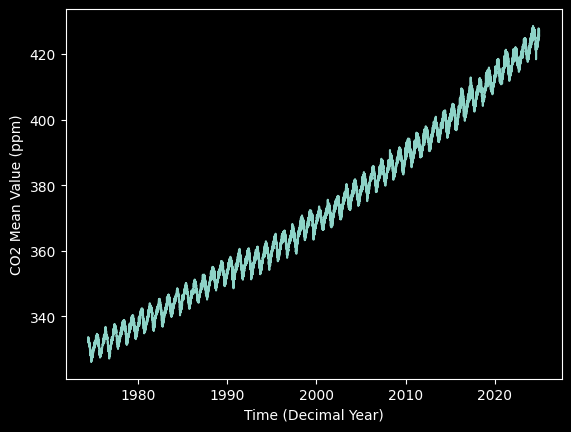

In [182]:
# create a plot of the data showing the temporal change in CO2 levels at Mauna Loa.
plt.figure()
plt.plot(data["Decimal Year"], data["CO2"])
plt.xlabel("Time (Decimal Year)")
plt.ylabel("CO2 Mean Value (ppm)")
plt.show()

Hopefully you can see that there is an increase in the atmospheric CO2 content but that this is a long term trend on a yearly flucuation in the atmospheric CO2 content of the Northern Hemisphere. Let's try to 'smooth out' that yearly variation by creating/calculating a moving average. For every timestamp in the dataframe calculate the average value in a year period surrounding that date (i.e., 0.5 years prior to 0.5 years after). 

(10 points)

Once you've calculated the moving average plot your results on the same graph as the daily CO2 values.

(5 points)

In [183]:
# Create a one-year moving average of the data and add it to the plot.
moving_avg = []
moving_time = []

window = 1.0

for i in range(len(data)):
    if data.loc[i, 'Decimal Year'] > np.nanmin(data.loc[:, 'Decimal Year']) + window/2:
        if data.loc[i, 'Decimal Year'] < np.nanmax(data.loc[:, 'Decimal Year']) - window/2:
            min_time = data.loc[i, 'Decimal Year'] - window/2
            max_time = data.loc[i, 'Decimal Year'] + window/2
            avg = np.nanmean(data.loc[(data['Decimal Year'] > min_time) & (data['Decimal Year'] < max_time), 'CO2'])
            moving_avg.append(avg)
            moving_time.append(data.loc[i, 'Decimal Year'])

In [184]:
len(moving_avg)

15235

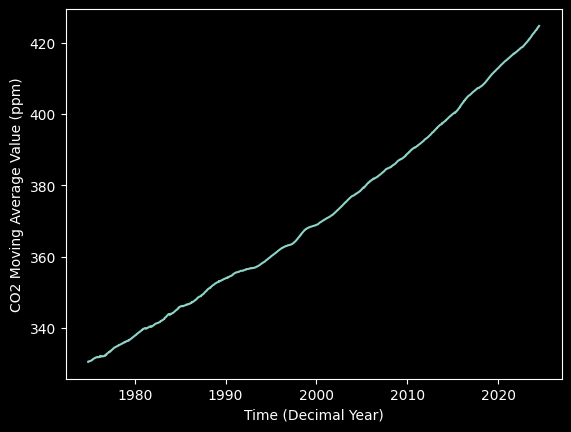

In [185]:
plt.figure()
plt.plot(moving_time, moving_avg)
plt.xlabel("Time (Decimal Year)")
plt.ylabel("CO2 Moving Average Value (ppm)")
plt.show()

Let's have a closer look at those yearly variations. Choose any year in the timeseries. Subtract the moving average value you just calculated from the CO2 daily mean for the same day and plot the CO2 - moving average curve for a single year. 

(20 points)

In [186]:
len(moving_time)

15235

In [187]:
len(data["CO2"])

15521

In [188]:
df_avg = pd.DataFrame(data={"Decimal Year": moving_time, "Moving Average": moving_avg})

In [189]:
df_moving_avg.head()

,Decimal Year,Moving Average
0,1974.8795,330.474281
1,1974.8822,330.463658
2,1974.8877,330.463121
3,1974.8904,330.465973
4,1974.8932,330.475853


In [190]:
# I chose 2004 (when I was born)
df_CO2_2004 = df_moving_avg.loc[np.floor(df_moving_avg["Decimal Year"]) == 2004,:]

In [191]:
# Add CO2 Daily Mean Value to the DataFrame
df_CO2_2004["CO2 Daily Mean"] = df_CO2_2004["Decimal Year"].map(data.set_index('Decimal Year')["CO2"])

In [192]:
df_CO2_2004.head()

,Decimal Year,Moving Average,CO2 Daily Mean
8656,2004.0000,377.051994,376.66
8657,2004.0027,377.059097,376.49
8658,2004.0055,377.065683,376.54
8659,2004.0082,377.069348,376.55
8660,2004.0109,377.077888,376.46


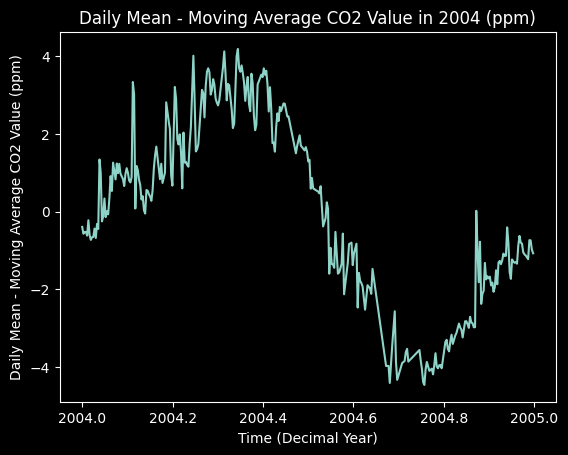

In [193]:
plt.figure()
plt.plot(df_CO2_2004["Decimal Year"], df_CO2_2004["CO2 Daily Mean"] - df_CO2_2004["Moving Average"])
plt.xlabel("Time (Decimal Year)")
plt.ylabel("Daily Mean - Moving Average CO2 Value (ppm)")
plt.title("Daily Mean - Moving Average CO2 Value in 2004 (ppm)")
plt.show()

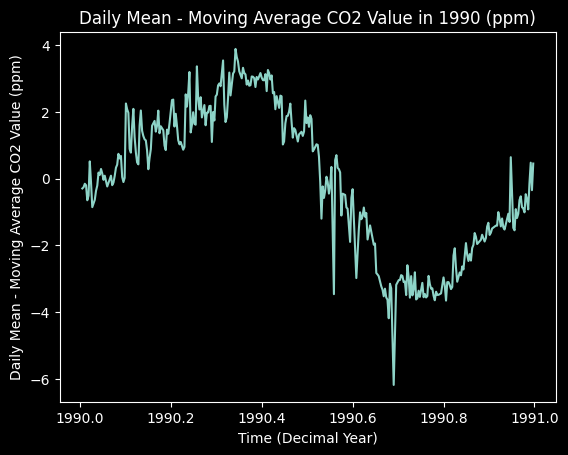

In [194]:
# Do the same thing to 1990
df_CO2_1990 = df_moving_avg.loc[np.floor(df_moving_avg["Decimal Year"]) == 1990,:]
df_CO2_1990["CO2 Daily Mean"] = df_CO2_1990["Decimal Year"].map(data.set_index('Decimal Year')["CO2"])

plt.figure()
plt.plot(df_CO2_1990["Decimal Year"], df_CO2_1990["CO2 Daily Mean"] - df_CO2_1990["Moving Average"])
plt.xlabel("Time (Decimal Year)")
plt.ylabel("Daily Mean - Moving Average CO2 Value (ppm)")
plt.title("Daily Mean - Moving Average CO2 Value in 1990 (ppm)")
plt.show()

Compare your results to someone else that chose a different year. Are the results similar? What do you think is driving these yearly variations?

(5 points)

Seasonal ppm trends are similar between 1990 and 2004．Some of the outliers in the data differ between the years. I think these outliers are caused by the natural phenomenon (e.g. Volcanic Activity); therefore, the yearly variations occured.

## Exercise 4 - Temperature vs CO2 contents

Below we will load in yearly global surface temperature anomalies (relative to the mean surface temperature between 1951 and 1980) and compare this to the CO2 curve. However, to compare this daily data to the yearly temperature data we first need to convert our CO2 data into a form that can be directly compared to the temperature anomalies (i.e., yearly data). One option would be to simply calculate the mean CO2 content each year (something that you've already done within the moving averages). However, to practice your data handling with NumPy and Pandas we're going to do it a little differently! 

Here I want you to calculate the mean and standard deviation of the atmospheric CO2 contents in the month of July for each year (and plot these on top of the moving average).

(10 points)

In [195]:
# Mean
data_july_mean = data.loc[data["Month"]==7].groupby('Year')['CO2'].mean()

In [196]:
# Standard deviation
data_july_std = data.loc[data["Month"]==7].groupby('Year')['CO2'].std()

In [197]:
data_july = pd.DataFrame({"mean": data_july_mean, "std": data_july_std})

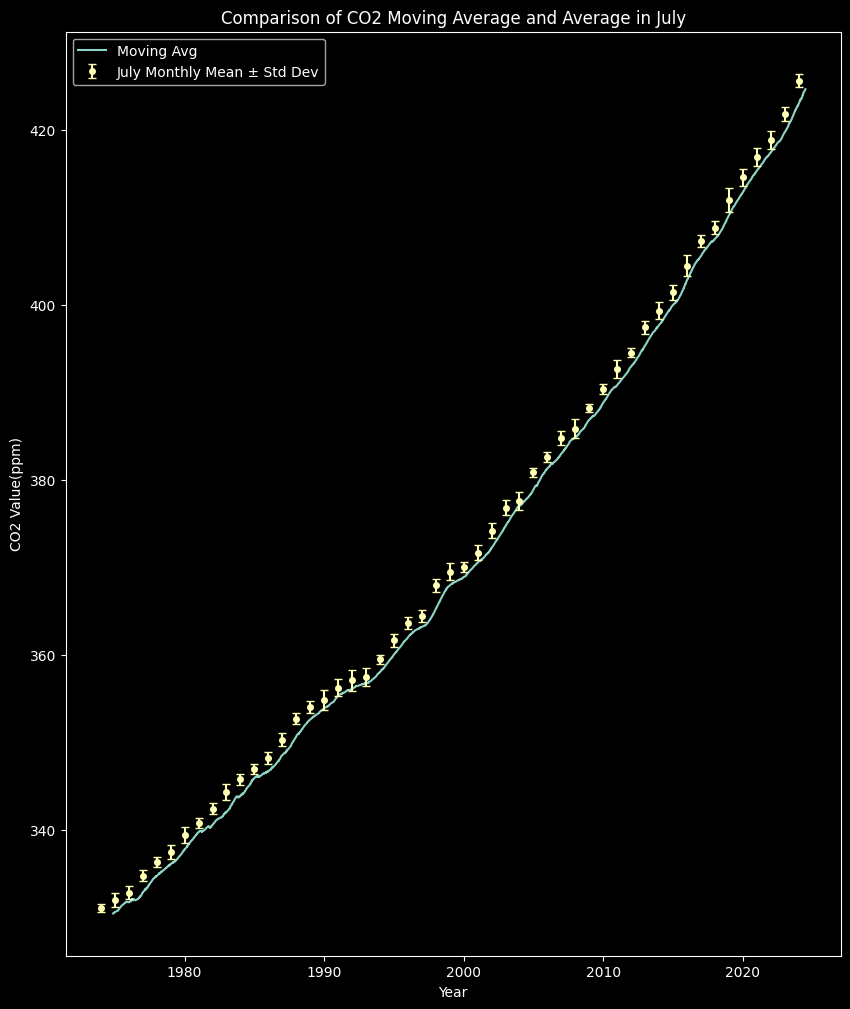

In [198]:
plt.figure(figsize=(10, 12))
plt.plot(moving_time, moving_avg, label="Moving Avg")
plt.errorbar(data_july_std.index, data_july_mean, yerr=data_july_std, fmt='o', markersize=4, capsize=3, label="July Monthly Mean ± Std Dev")
plt.xlabel("Year")
plt.ylabel("CO2 Value(ppm)")
plt.title("Comparison of CO2 Moving Average and Average in July")
plt.legend()
plt.show()

Now let's load in the temperature data (sourced from https://climate.nasa.gov/vital-signs/global-temperature/?intent=121).

In [199]:
## Load global temperature data from https://climate.nasa.gov/vital-signs/global-temperature/?intent=121
temp = pd.read_csv('data/T_records.csv')
print(temp.head())
print(temp.tail())

   Year  Yearly Average  Lowess Smoothing
0  1880           -0.17             -0.10
1  1881           -0.09             -0.13
2  1882           -0.11             -0.17
3  1883           -0.18             -0.20
4  1884           -0.28             -0.24
     Year  Yearly Average  Lowess Smoothing
139  2019            0.97              0.93
140  2020            1.00              0.94
141  2021            0.84              0.96
142  2022            0.89              0.98
143  2023            1.17              1.00


Create a plot that shows the yearly temperature anomaly on the x axis and the mean July CO2 content on the y-axis. The challenge here is that the two datasets are different sizes! Your challenge is to work out how to solve this issue!

(15 points)

In [200]:
df_merged_temp_co2 = pd.merge(temp, data_july_mean, on="Year")
print(df_merged_temp_co2.head())
print(df_merged_temp_co2.tail())

   Year  Yearly Average  Lowess Smoothing         CO2
0  1974           -0.07              0.01  331.110000
1  1975           -0.01              0.02  332.037500
2  1976           -0.10              0.04  332.887333
3  1977            0.18              0.07  334.808500
4  1978            0.07              0.12  336.342381
    Year  Yearly Average  Lowess Smoothing         CO2
45  2019            0.97              0.93  412.008000
46  2020            1.00              0.94  414.603000
47  2021            0.84              0.96  416.897419
48  2022            0.89              0.98  418.851111
49  2023            1.17              1.00  421.820952


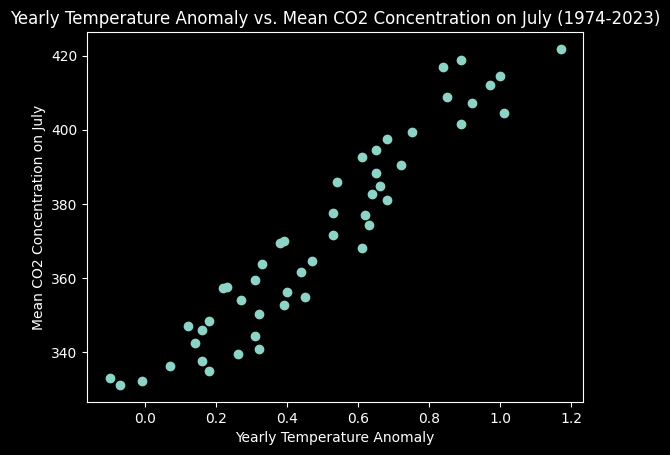

In [201]:
plt.figure()
plt.scatter(df_merged_temp_co2["Yearly Average"], df_merged_temp_co2["CO2"])
plt.xlabel("Yearly Temperature Anomaly")
plt.ylabel("Mean CO2 Concentration on July")
plt.title("Yearly Temperature Anomaly vs. Mean CO2 Concentration on July (1974-2023)")
plt.show()

 ### Extra code - this will calculate a simple regression through the data and plot the regression line and confidence interval for the regression. The low p-value indicates that this correlation is almost certainly not random chance!

In [208]:
print(data_july_mean.head())
print(df_merged_temp_co2.head())

Year
1974    331.110000
1975    332.037500
1976    332.887333
1977    334.808500
1978    336.342381
Name: CO2, dtype: float64
   Year  Yearly Average  Lowess Smoothing         CO2
0  1974           -0.07              0.01  331.110000
1  1975           -0.01              0.02  332.037500
2  1976           -0.10              0.04  332.887333
3  1977            0.18              0.07  334.808500
4  1978            0.07              0.12  336.342381


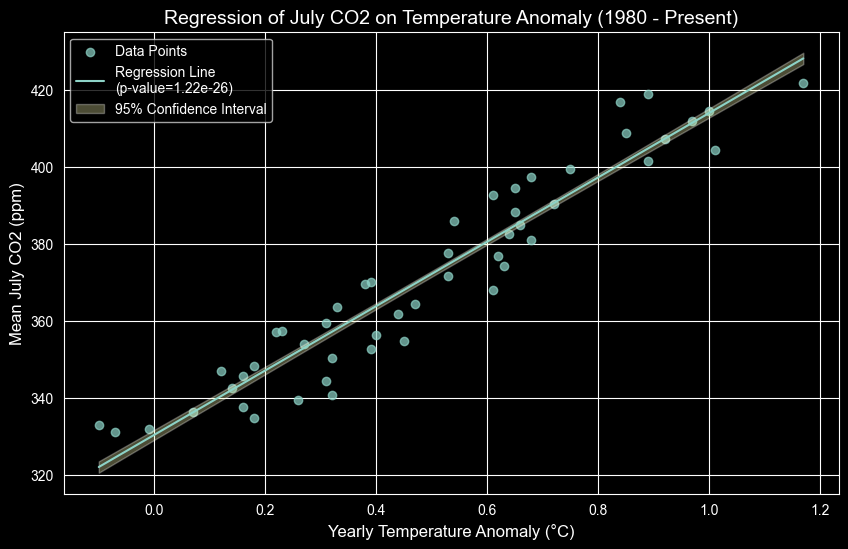

In [214]:
import seaborn as sns
from scipy.stats import linregress

# Data Preparation (assuming temp_filtered and july_co2_mean are defined)
x = df_merged_temp_co2['Yearly Average'].values
y = df_merged_temp_co2['CO2'].values

# Linear Regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_new = np.linspace(np.nanmin(df_merged_temp_co2['Yearly Average']), np.nanmax(df_merged_temp_co2['Yearly Average']), 101)
y_pred = slope * x_new + intercept

# Confidence Intervals
n = len(x_new)
t_val = 1.96  # Approx. for 95% confidence
y_err = t_val * std_err * np.sqrt(1/n + ((x_new - np.mean(x_new))**2) / np.sum((x_new - np.mean(x_new))**2))
y_lower = y_pred - y_err
y_upper = y_pred + y_err

# Plotting
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(x, y, label='Data Points', alpha=0.7)

# Regression line
plt.plot(x_new, y_pred, label=f'Regression Line\n(p-value={p_value:.2e})')

# Confidence intervals
plt.fill_between(x_new, y_lower, y_upper,alpha=0.3, label='95% Confidence Interval')

# Labels and Title
plt.xlabel('Yearly Temperature Anomaly (°C)', fontsize=12)
plt.ylabel('Mean July CO2 (ppm)', fontsize=12)
plt.title('Regression of July CO2 on Temperature Anomaly (1980 - Present)', fontsize=14)
plt.legend()
plt.show()


## Exercise 5 - Isotope records of climate variability

Read these two articles: https://gml.noaa.gov/education/isotopes/c14tellsus.html; https://gml.noaa.gov/education/isotopes/c13tellsus.html

The dominant form of Carbon in our atmosphere is Carbon-12 (made up of 6 protons and 6 neutrons). However, there are two other forms of Carbon: Carbon-13 (7 neutrons), a stable isotope of Carbon that accounts for ~1% of the global Carbon; and Carbon-14, a radioactive isotope formed via interation of cosmic rays with Nitrogen-14 atoms in Earth's atmosphere. C-14 has a 'half-life' of 5730 years, meaning that after this amount of time half of the initial atoms of C-14 in a substance will undergo radioactive decay to N-14 (via beta decay). Watch this YouTube video on radioactive decay for more information: https://www.youtube.com/watch?v=IDkNlU7zKYU.

Interestingly, all life is dominantly formed from C-bearing molecules/compounts and prefers to use the C-12 isotope relative to C-13 (i.e., any biological material will have a low C-13/C-12 ratio compared to the atmosphere/oceans. That means that the plant and animal life that formed the coal and oil/gas deposits we have been burning for the last 250 years will have a lower C-13/C-12 ratio than the pre-industrial revolution atmosphere. What will happen when that Carbon is burnt in power stations and released to the atmosphere?

Some people still dispute that the rise in global temperatures is caused by burning of fossil fuels. How does the C isotope data help to show us that: (i) the rise in CO2 in the atmosphere is driven by buring fossil fuels (as opposed to natural sources of CO2 e.g., volcanoes); (ii) the rise in global temperatures is this also related to human related fuel emissions. Use the markdown cells below to write a short answer.

(10 points)